# Análise Exploratória dos Dados de NPS

Este notebook analisa a satisfação dos clientes de um e-commerce a partir da nota de NPS.



# 1. Entendimento do negócio

O problema de negócio é entender quais gargalos na jornada de compra estão reduzindo a satisfação dos clientes e como a empresa pode agir antes que a insatisfação se transforme em perda de recompra, reclamações e percepção negativa da marca.

A base mostra dados de pedido, entrega, atendimento, reclamações, recompra e satisfação. Portanto, a pergunta central pode ser formulada assim:

> **Quais aspectos da experiência de compra mais influenciam o NPS do cliente e quais sinais operacionais indicam maior risco de insatisfação?**

O NPS é importante porque funciona como um termômetro da experiência do cliente. Neste caso, por ser um e-commerce, a satisfação não depende só do produto, mas da combinação entre preço, prazo, entrega, frete, atendimento e resolução de problemas. Um cliente detrator tende a recomprar menos, reclamar mais e prejudicar a reputação da marca por boca a boca ou avaliações públicas.

As áreas que mais poderiam se beneficiar desses insights são:

- **Logística:** entender o impacto de atrasos, tempo de entrega e tentativas de entrega.
- **Atendimento:** priorizar casos com maior risco de insatisfação, principalmente clientes com muitos contatos ou demora na resolução.
- **Produto/Operações:** identificar padrões de pedidos que geram mais atrito.
- **Marketing/CRM:** criar ações de retenção para clientes com maior risco de virarem detratores.
- **Estratégia:** acompanhar o impacto da experiência na recompra e na fidelização.

O NPS impacta diretamente três frentes de negócio:

- **Recompra:** clientes promotores tendem a voltar com mais frequência, enquanto detratores podem abandonar a marca.
- **Boca a boca:** promotores ajudam na aquisição orgânica, enquanto detratores podem gerar avaliações negativas.
- **Market share:** uma experiência superior pode diferenciar a empresa em um mercado competitivo, especialmente quando preço e sortimento são parecidos entre concorrentes.

Indicadores complementares úteis seriam: SLA de entrega, taxa de atraso, tempo médio de resolução, volume de reclamações, taxa de recompra, churn, avaliações em canais públicos, benchmarks de NPS do setor e comparação com concorrentes.

## 2. Definição da Target

A variável que representa a satisfação do cliente é `nps_score`.

Ela foi escolhida porque mede diretamente a percepção do cliente após a experiência de compra, em uma escala de 0 a 10. Na base analisada, essa variável permite avaliar o nível de satisfação e também criar categorias de negócio:

- **Detrator:** `nps_score <= 5`
- **Neutro:** `nps_score > 5 e < 8`
- **Promotor:** `nps_score >= 8`

Essa classificação permite analisar não apenas a nota média, mas também o comportamento dos clientes em diferentes níveis de satisfação. Do ponto de vista do negócio, os detratores merecem atenção especial, pois representam clientes com maior risco de insatisfação, menor chance de recompra e maior possibilidade de gerar reclamações ou percepção negativa sobre a marca.

A informação de NPS é coletada após a jornada de compra, quando o cliente já passou pelas etapas de pedido, pagamento, entrega e possível contato com atendimento. Por isso, ela reflete a experiência final do cliente com a empresa.

Com a regra adotada, a base apresenta a seguinte distribuição:

- **Detratores:** 1.507 clientes, representando 60,3% da base;
- **Neutros:** 775 clientes, representando 31,0% da base;
- **Promotores:** 218 clientes, representando 8,7% da base.

O NPS calculado, considerando `% promotores - % detratores`, é de **-51,6**. Esse resultado indica um cenário crítico de satisfação, pois a proporção de clientes detratores é muito superior à de promotores.

Existe também um risco importante no uso da variável alvo. Como o `nps_score` é coletado depois da experiência, é necessário cuidado para não usar no modelo variáveis que só existem após esse mesmo momento. Por exemplo, `repeat_purchase_30d` pode ser consequência da satisfação, e não uma informação disponível antes da pesquisa. O mesmo cuidado vale para `csat_internal_score`, dependendo de quando ele é calculado. Esse tipo de variável pode gerar vazamento de informação e fazer o modelo parecer melhor do que realmente seria na prática.


## 1. Importação das bibliotecas

Nesta etapa importamos as bibliotecas usadas na análise:

- `pandas` e `numpy` para manipulação dos dados;
- `matplotlib` e `seaborn` para gráficos;
- `Path` para trabalhar com caminhos de arquivos.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Configurações para exibição de dados e gráficos
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Carregamento da base


In [44]:
DATA_PATH = Path('../data/raw/desafio_nps_fase_1.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/desafio_nps_fase_1.csv')

nps_ecom = pd.read_csv(DATA_PATH)

print(f'Linhas: {nps_ecom.shape[0]:,}')
print(f'Colunas: {nps_ecom.shape[1]:,}')
display(nps_ecom.head())


Linhas: 2,500
Colunas: 19


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


## 3. Criação dos grupos de NPS

Para comparar clientes com diferentes níveis de satisfação classificamos a nota de NPS em 3 grupos:

- **Detrator:** `nps_score <= 5`
- **Neutro:** `nps_score > 5 e < 8`
- **Promotor:** `nps_score >= 8`



In [45]:
nps_eda = nps_ecom.copy()

nps_eda['nps_group'] = np.select(
    [
        nps_eda['nps_score'] <= 5,
        (nps_eda['nps_score'] > 5) & (nps_eda['nps_score'] < 8),
        nps_eda['nps_score'] >= 8
    ],
    ['Detrator', 'Neutro', 'Promotor'],
    default='Indefinido'
)

nps_eda['is_detractor'] = (nps_eda['nps_score'] <= 5).astype(int)
nps_eda['is_promoter'] = (nps_eda['nps_score'] >= 8).astype(int)

nps_eda[['nps_score', 'nps_group', 'is_detractor', 'is_promoter']].head()


,nps_score,nps_group,is_detractor,is_promoter
0,6.90,Neutro,0,0
1,2.40,Detrator,1,0
2,4.80,Detrator,1,0
3,5.90,Neutro,0,0
4,6.10,Neutro,0,0


## 4. Visão geral do NPS

Aqui calculamos a distribuição dos clientes entre detratores, neutros e promotores. Também calculamos o NPS geral pela fórmula: **% Promotores - % Detratores**


In [46]:
nps_distribution = (
    nps_eda['nps_group']
    .value_counts()
    .reindex(['Detrator', 'Neutro', 'Promotor'])
    .reset_index()
)

nps_distribution.columns = ['grupo_nps', 'quantidade']
nps_distribution['percentual'] = (nps_distribution['quantidade'] / len(nps_eda) * 100).round(1)

nps_score_calculado = (
    nps_eda['is_promoter'].mean() - nps_eda['is_detractor'].mean()
) * 100

print(f'NPS médio: {nps_eda["nps_score"].mean():.2f}')
print(f'NPS calculado: {nps_score_calculado:.1f}')
display(nps_distribution)


NPS médio: 4.38
NPS calculado: -51.6


,grupo_nps,quantidade,percentual
0,Detrator,1507,60.30
1,Neutro,775,31.00
2,Promotor,218,8.70


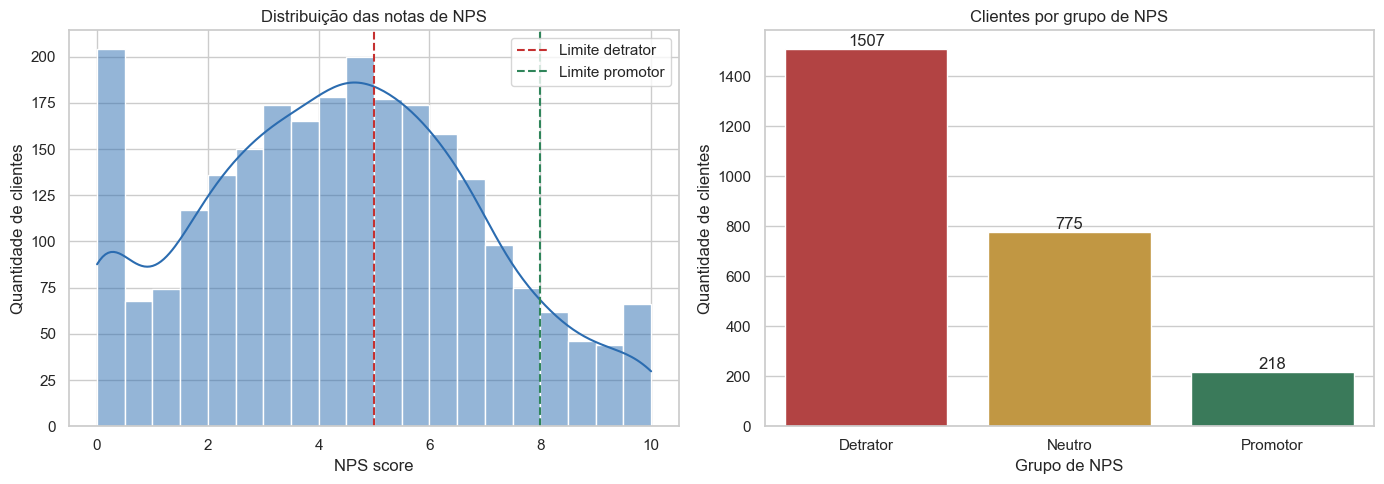

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de distribuição do NPS score
sns.histplot(data=nps_eda, x='nps_score', bins=20, kde=True, color='#2B6CB0', ax=axes[0])
axes[0].axvline(5, color='#C53030', linestyle='--', label='Limite detrator')
axes[0].axvline(8, color='#2F855A', linestyle='--', label='Limite promotor')
axes[0].set_title('Distribuição das notas de NPS')
axes[0].set_xlabel('NPS score')
axes[0].set_ylabel('Quantidade de clientes')
axes[0].legend()

# Gráfico de barras para a distribuição dos grupos de NPS
sns.barplot(data=nps_distribution,
            x='grupo_nps',
            y='quantidade',
            hue='grupo_nps',
            palette=['#C53030', '#D69E2E', '#2F855A'],
            legend=False,
            ax=axes[1]) 
axes[1].set_title('Clientes por grupo de NPS')
axes[1].set_xlabel('Grupo de NPS')
axes[1].set_ylabel('Quantidade de clientes')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()


### Insight 1 - A satisfação geral está em ponto de atenção

Com a regra de classificação adotada, a maior parte dos clientes está concentrada no grupo de detratores. Na prática, isso mostra que a empresa possui mais clientes insatisfeitos do que clientes realmente encantados com a experiência, o que pode impactar indicadores importantes como recompra, fidelização, reputação da marca e crescimento do negócio.

Embora exista uma parcela relevante de clientes neutros, a quantidade de promotores ainda é relativamente baixa. Isso sugere que a principal oportunidade está em reduzir os atritos ao longo da jornada do cliente, atuando de forma preventiva nos pontos que geram insatisfação. Com isso, a empresa pode não apenas diminuir o volume de detratores, mas também aumentar a conversão de clientes neutros em promotores, fortalecendo a satisfação e a lealdade à marca.

## 5. Correlação com o NPS

A correlação ajuda a identificar quais variáveis se relacionam mais com a nota de NPS. Ela não prova causa e efeito, mas ajuda a priorizar hipóteses para investigação.


In [50]:
#Renomeando as colunas para facilitar a leitura e interpretação dos dados
nomes_variaveis = {
    'customer_age': 'Idade do cliente',
    'customer_tenure_months': 'Tempo de relacionamento',
    'order_value': 'Valor do pedido',
    'items_quantity': 'Quantidade de itens',
    'discount_value': 'Valor do desconto',
    'payment_installments': 'Parcelas do pagamento',
    'customer_id': 'ID do cliente',
    'order_id': 'ID do pedido',
    'delivery_time_days': 'Tempo de entrega',
    'delivery_delay_days': 'Atraso na entrega',
    'freight_value': 'Valor do frete',
    'delivery_attempts': 'Tentativas de entrega',
    'customer_service_contacts': 'Contatos com atendimento',
    'resolution_time_days': 'Tempo de resolução',
    'repeat_purchase_30d': 'Recompra em 30 dias',
    'complaints_count': 'Quantidade de reclamações',
    'csat_internal_score': 'CSAT interno',
    'is_detractor': 'Cliente detrator',
    'is_promoter': 'Cliente promotor'
}

In [51]:
#Analisando a correlação entre as variáveis numéricas e o NPS score
colunas_numericas = nps_eda.select_dtypes(include='number').columns

correlacao_nps = (
    nps_eda[colunas_numericas]
    .corr()['nps_score']
    .drop('nps_score')
    .sort_values(key=abs, ascending=False)
)

correlacao_nps_nomeada = correlacao_nps.rename(index=nomes_variaveis)

display(correlacao_nps_nomeada.round(3).to_frame('Correlação com NPS'))

,Correlação com NPS
Cliente detrator,-0.81
Atraso na entrega,-0.60
Recompra em 30 dias,0.57
Cliente promotor,0.57
CSAT interno,0.56
Quantidade de reclamações,-0.50
Contatos com atendimento,-0.35
Tempo de resolução,-0.19
Valor do frete,-0.04
Valor do pedido,0.04


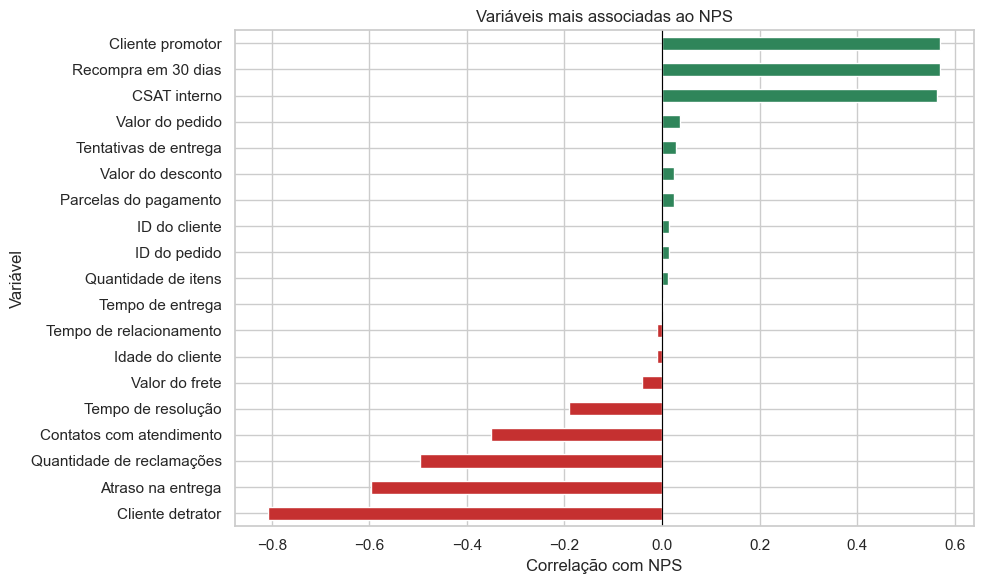

In [52]:
#Gráfico de barras para as variáveis mais associadas ao NPS
correlacao_plot = correlacao_nps_nomeada.sort_values()

plt.figure(figsize=(10, 6))

correlacao_plot.plot(
    kind='barh',
    color=['#C53030' if valor < 0 else '#2F855A' for valor in correlacao_plot]
)

plt.title('Variáveis mais associadas ao NPS')
plt.xlabel('Correlação com NPS')
plt.ylabel('Variável')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Insight 2 - Os principais sinais estão ligados à operação

As variáveis com maior relação com o NPS estão diretamente ligadas à experiência vivida pelo cliente ao longo da jornada, especialmente fatores operacionais como atraso na entrega, abertura de reclamações, quantidade de contatos com o atendimento, tempo de resolução dos problemas e CSAT interno.

Esse resultado indica que a satisfação do cliente está muito mais relacionada à qualidade da experiência oferecida pela empresa do que às características do próprio cliente. Em outras palavras, o que mais influencia a percepção final não é quem o cliente é, mas sim como a compra aconteceu e quais atritos ele encontrou durante o processo.


## 6. Comparação entre detratores, neutros e promotores

Nesta etapa comparamos as médias dos principais indicadores por grupo de NPS. A ideia é entender como a experiência muda entre clientes insatisfeitos, neutros e satisfeitos.


In [53]:
#Renomeando as colunas para facilitar a leitura e interpretação dos dados
colunas_comparacao = [
    'delivery_delay_days',
    'delivery_time_days',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    'csat_internal_score',
    'repeat_purchase_30d',
    'order_value',
    'freight_value'
]

#Comparando as médias das variáveis mais associadas ao NPS entre os grupos de clientes
comparacao_grupos = (
    nps_eda
    .groupby('nps_group')[colunas_comparacao]
    .mean()
    .reindex(['Detrator', 'Neutro', 'Promotor'])
    .round(2)
)

display(comparacao_grupos)


,delivery_delay_days,delivery_time_days,customer_service_contacts,resolution_time_days,complaints_count,csat_internal_score,repeat_purchase_30d,order_value,freight_value
nps_group,,,,,,,,,
Detrator,2.71,8.05,1.79,5.96,4.75,2.04,0.00,427.69,38.54
Neutro,1.56,7.96,1.19,4.94,3.46,3.95,0.00,440.86,37.87
Promotor,0.76,8.10,0.80,4.11,2.42,5.58,1.00,456.23,37.22


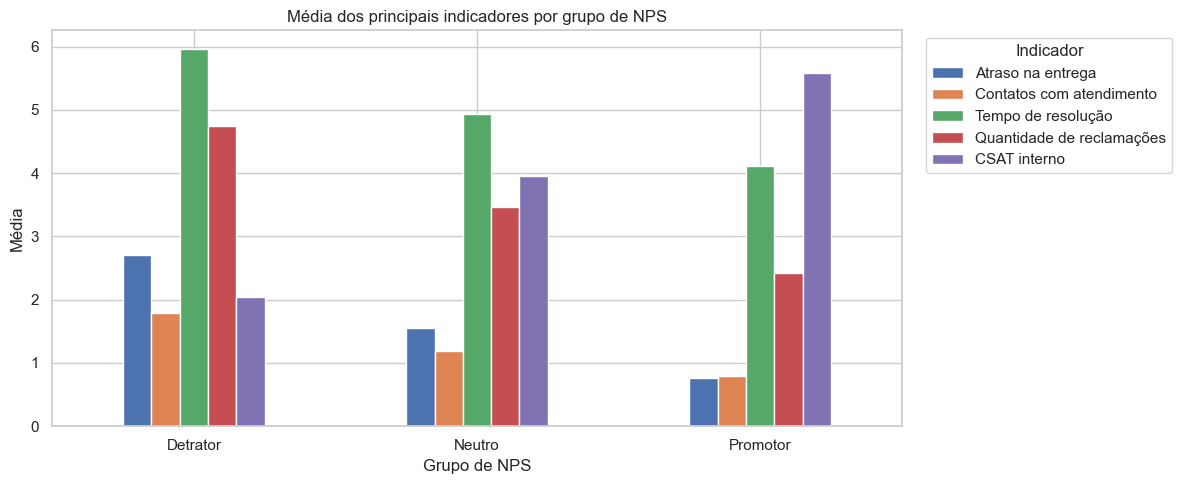

In [54]:
#Renomeando as colunas para facilitar a leitura e interpretação dos dados
indicadores_operacionais = [
    'delivery_delay_days',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    'csat_internal_score'
]

nomes_indicadores = {
    'delivery_delay_days': 'Atraso na entrega',
    'customer_service_contacts': 'Contatos com atendimento',
    'resolution_time_days': 'Tempo de resolução',
    'complaints_count': 'Quantidade de reclamações',
    'csat_internal_score': 'CSAT interno'
}

#Gráfico de barras comparando os principais indicadores operacionais entre os grupos de NPS
comparacao_plot = comparacao_grupos[indicadores_operacionais].rename(
    columns=nomes_indicadores
)

comparacao_plot.plot(kind='bar', figsize=(12, 5))

plt.title('Média dos principais indicadores por grupo de NPS')
plt.xlabel('Grupo de NPS')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.legend(title='Indicador', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Insight 3 - Clientes detratores acumulam mais problemas

Os clientes classificados como detratores apresentam, em média, mais atrasos nas entregas, maior volume de reclamações, mais interações com o atendimento e níveis mais baixos de CSAT interno. Esse comportamento mostra que a insatisfação dificilmente surge de um único evento isolado. Na maioria dos casos, ela é resultado do acúmulo de atritos ao longo da jornada, fazendo com que a percepção do cliente sobre a experiência seja progressivamente impactada.


## 7. Atraso na entrega

A entrega é uma etapa crítica no e-commerce. Nesta análise, agrupamos os pedidos por dias de atraso para observar como o NPS muda conforme o atraso aumenta.


In [56]:
#Analisando o impacto do atraso na entrega no NPS
nps_eda['faixa_atraso'] = pd.cut(
    nps_eda['delivery_delay_days'],
    bins=[-1, 0, 1, 2, 3, 5, np.inf],
    labels=['Sem atraso', '1 dia', '2 dias', '3 dias', '4-5 dias', 'Acima de 5 dias']
)

#Agrupando por faixa de atraso e calculando métricas de NPS para cada grupo
atraso_nps = (
    nps_eda
    .groupby('faixa_atraso', observed=True)
    .agg(
        qtd_clientes=('nps_score', 'size'),
        nps_medio=('nps_score', 'mean'),
        detratores_pct=('is_detractor', 'mean'),
        promotores_pct=('is_promoter', 'mean')
    )
    .reset_index()
)

atraso_nps['detratores_pct'] = (atraso_nps['detratores_pct'] * 100).round(1)
atraso_nps['promotores_pct'] = (atraso_nps['promotores_pct'] * 100).round(1)
atraso_nps['nps_medio'] = atraso_nps['nps_medio'].round(2)

#Renomeando as colunas para facilitar a leitura e interpretação dos dados
atraso_nps = atraso_nps.rename(columns={
    'faixa_atraso': 'Faixa de atraso',
    'qtd_clientes': 'Qtd. clientes',
    'nps_medio': 'NPS médio',
    'detratores_pct': '% detratores',
    'promotores_pct': '% promotores'
})

display(atraso_nps)

,Faixa de atraso,Qtd. clientes,NPS médio,% detratores,% promotores
0,Sem atraso,277,6.86,19.90,33.90
1,1 dia,615,5.55,43.10,14.80
2,2 dias,646,4.58,57.60,4.00
3,3 dias,525,3.44,78.50,1.10
4,4-5 dias,386,2.15,91.20,0.30
5,Acima de 5 dias,51,0.81,100.00,0.00


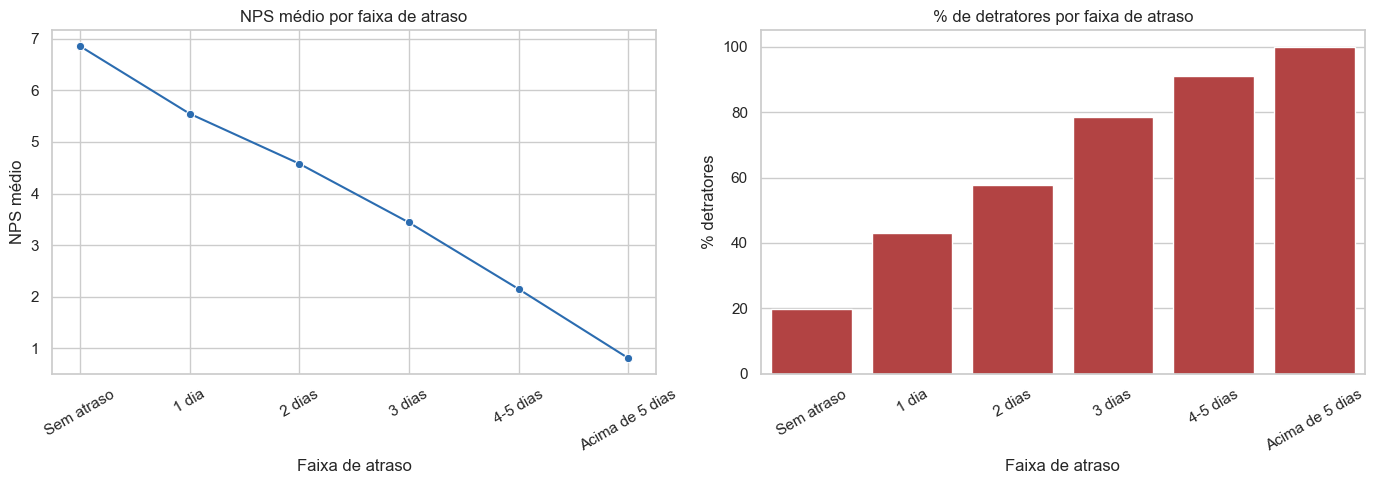

In [57]:
from turtle import color

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico de linha para o NPS médio por faixa de atraso
sns.lineplot(data=atraso_nps, x='Faixa de atraso', y='NPS médio', marker='o', color='#2B6CB0', ax=axes[0])
axes[0].set_title('NPS médio por faixa de atraso')
axes[0].set_xlabel('Faixa de atraso')
axes[0].set_ylabel('NPS médio')
axes[0].tick_params(axis='x', rotation=30)

#Gráfico de barras para o percentual de detratores por faixa de atraso
sns.barplot(data=atraso_nps, x='Faixa de atraso', y='% detratores', color='#C53030', ax=axes[1])
axes[1].set_title('% de detratores por faixa de atraso')
axes[1].set_xlabel('Faixa de atraso')
axes[1].set_ylabel('% detratores')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### Insight 4 - O atraso é um dos principais pontos de ruptura

Os resultados mostram que, à medida que o atraso na entrega aumenta, o NPS médio tende a diminuir e a participação de clientes detratores cresce significativamente. Esse comportamento reforça que atrasos são um dos principais sinais de risco para a satisfação do cliente e têm impacto direto na percepção da experiência.

Do ponto de vista do negócio, esse é um indicador especialmente relevante por permitir ações preventivas. Pedidos com atraso ou com alta probabilidade de atraso podem ser identificados antecipadamente e receber comunicação proativa, acompanhamento mais próximo e priorização operacional, reduzindo o impacto negativo na experiência e aumentando as chances de preservar a satisfação do cliente.


## 8. Reclamações e atendimento

Além da entrega, também analisamos reclamações e contatos com atendimento. Essas variáveis ajudam a medir o esforço que o cliente precisou fazer para resolver algum problema.


In [58]:
#Analisando o impacto do número de reclamações e contatos com atendimento no NPS
nps_eda['faixa_reclamacoes'] = pd.cut(
    nps_eda['complaints_count'],
    bins=[-1, 0, 1, 2, 3, 5, np.inf],
    labels=['0', '1', '2', '3', '4-5', 'Acima de 5']
)

#Criando faixas para o número de contatos com atendimento
nps_eda['faixa_contatos'] = pd.cut(
    nps_eda['customer_service_contacts'],
    bins=[-1, 0, 1, 2, 3, np.inf],
    labels=['0', '1', '2', '3', 'Acima de 3']
)

#Agrupando por faixa de reclamações e calculando métricas de NPS para cada grupo
reclamacoes_nps = (
    nps_eda
    .groupby('faixa_reclamacoes', observed=True)
    .agg(nps_medio=('nps_score', 'mean'), detratores_pct=('is_detractor', 'mean'))
    .reset_index()
)

#Agrupando por faixa de contatos e calculando métricas de NPS para cada grupo
contatos_nps = (
    nps_eda
    .groupby('faixa_contatos', observed=True)
    .agg(nps_medio=('nps_score', 'mean'), detratores_pct=('is_detractor', 'mean'))
    .reset_index()
)

#Formatando os resultados para melhor visualização
reclamacoes_nps['nps_medio'] = reclamacoes_nps['nps_medio'].round(2)
reclamacoes_nps['detratores_pct'] = (reclamacoes_nps['detratores_pct'] * 100).round(1)

contatos_nps['nps_medio'] = contatos_nps['nps_medio'].round(2)
contatos_nps['detratores_pct'] = (contatos_nps['detratores_pct'] * 100).round(1)

display(reclamacoes_nps)
display(contatos_nps)


,faixa_reclamacoes,nps_medio,detratores_pct
0,0,8.52,0.00
1,1,7.77,1.60
2,2,6.05,29.20
3,3,4.91,51.70
4,4-5,3.98,68.50
5,Acima de 5,2.82,84.80


,faixa_contatos,nps_medio,detratores_pct
0,0,5.54,42.40
1,1,4.66,55.40
2,2,4.12,65.60
3,3,3.20,78.30
4,Acima de 3,2.47,87.50


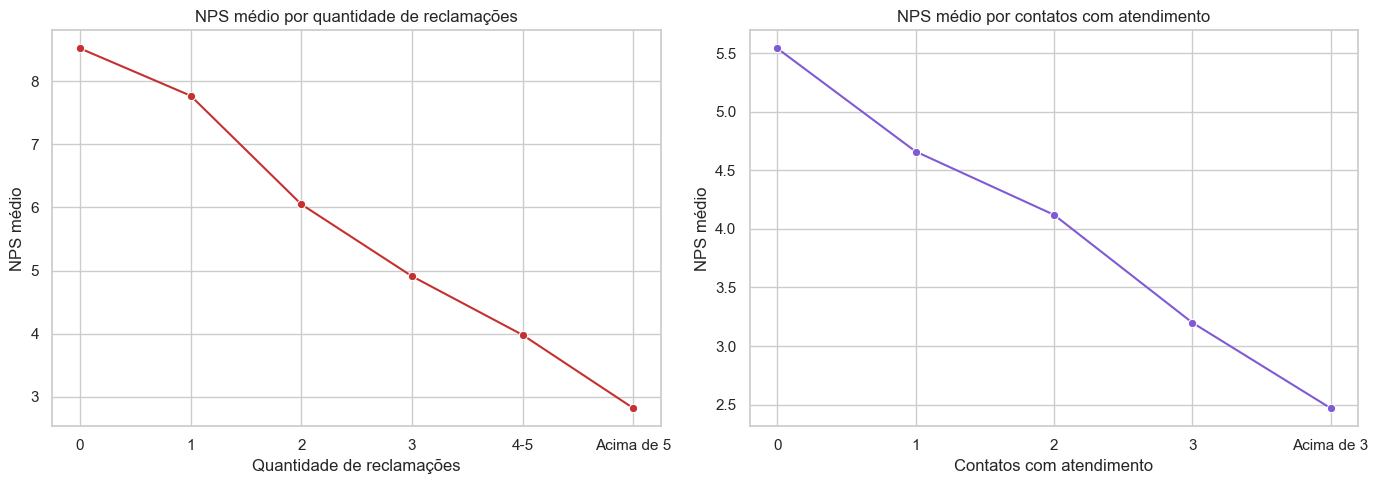

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico de linha para o NPS médio por faixa de reclamações
sns.lineplot(data=reclamacoes_nps, x='faixa_reclamacoes', y='nps_medio', marker='o', color='#C53030', ax=axes[0])
axes[0].set_title('NPS médio por quantidade de reclamações')
axes[0].set_xlabel('Quantidade de reclamações')
axes[0].set_ylabel('NPS médio')

#Gráfico de linha para o NPS médio por faixa de contatos
sns.lineplot(data=contatos_nps, x='faixa_contatos', y='nps_medio', marker='o', color='#805AD5', ax=axes[1])
axes[1].set_title('NPS médio por contatos com atendimento')
axes[1].set_xlabel('Contatos com atendimento')
axes[1].set_ylabel('NPS médio')

plt.tight_layout()
plt.show()


### Insight 5 - Mais esforço do cliente está associado a menor satisfação

Os dados mostram que clientes que precisam abrir mais reclamações ou realizar múltiplos contatos com o atendimento tendem a apresentar níveis mais baixos de NPS. Isso sugere que a percepção da experiência não é impactada apenas pelo problema em si, mas também pelo esforço necessário para resolvê-lo.

Esse resultado reforça a importância de tornar a jornada de suporte mais simples e eficiente. Reduzir retrabalho, acelerar o tempo de resolução e aumentar a efetividade do atendimento já no primeiro contato são ações que podem contribuir diretamente para a redução da insatisfação e para a melhora dos indicadores de experiência do cliente.


## 9. Região e perfil do cliente

Também analisamos se a satisfação muda por região. Essa leitura ajuda a verificar se o problema está concentrado em algum mercado específico.


In [60]:
#Analisando o NPS médio por região geográfica dos clientes
regiao_nps = (
    nps_eda
    .groupby('customer_region')
    .agg(
        qtd_clientes=('nps_score', 'size'),
        nps_medio=('nps_score', 'mean'),
        detratores_pct=('is_detractor', 'mean'),
        promotores_pct=('is_promoter', 'mean')
    )
    .reset_index()
)

#Formatando os resultados para melhor visualização
regiao_nps['nps_medio'] = regiao_nps['nps_medio'].round(2)
regiao_nps['detratores_pct'] = (regiao_nps['detratores_pct'] * 100).round(1)
regiao_nps['promotores_pct'] = (regiao_nps['promotores_pct'] * 100).round(1)

regiao_nps = regiao_nps.sort_values('nps_medio')

regiao_nps = regiao_nps.rename(columns={
    'customer_region': 'Região',
    'qtd_clientes': 'Qtd. clientes',
    'nps_medio': 'NPS médio',
    'detratores_pct': '% detratores',
    'promotores_pct': '% promotores'
})

display(regiao_nps)

,Região,Qtd. clientes,NPS médio,% detratores,% promotores
0,Centro-Oeste,468,4.21,63.90,8.30
3,Sudeste,520,4.37,60.00,8.80
2,Norte,506,4.38,58.30,7.90
1,Nordeste,485,4.42,59.20,7.60
4,Sul,521,4.49,60.30,10.70


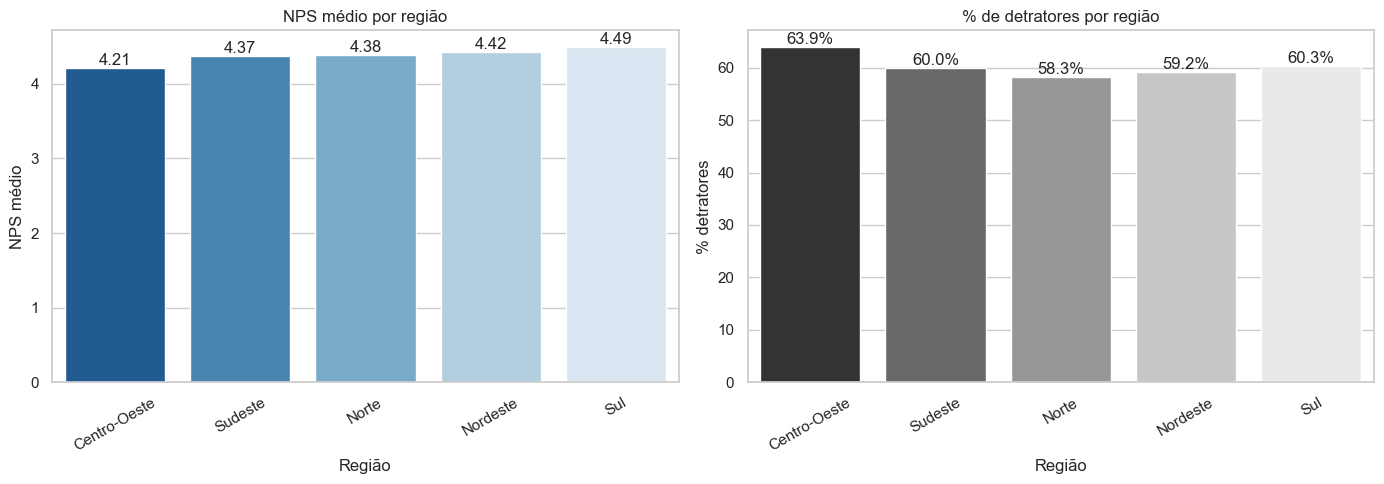

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico de barras para o NPS médio por região
sns.barplot(
    data=regiao_nps,
    x='Região',
    y='NPS médio',
    hue='Região',
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('NPS médio por região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('NPS médio')
axes[0].tick_params(axis='x', rotation=30)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')

#Gráfico de barras para o percentual de detratores por região
sns.barplot(
    data=regiao_nps,
    x='Região',
    y='% detratores',
    hue='Região',
    palette='Greys_r',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('% de detratores por região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('% detratores')
axes[1].tick_params(axis='x', rotation=30)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Insight 6 - O problema não parece ser apenas regional

As análises por região mostram algumas diferenças nos níveis de satisfação, porém essas variações, isoladamente, não são suficientes para explicar o baixo NPS observado. Os fatores com maior impacto continuam sendo os relacionados à experiência operacional, como atrasos na entrega, volume de reclamações e necessidade de interação com o atendimento.

Isso sugere que, embora existam particularidades regionais, a principal causa da insatisfação está nos atritos enfrentados ao longo da jornada de compra. Portanto, iniciativas voltadas para a melhoria dos processos operacionais tendem a gerar um impacto mais relevante na satisfação do cliente do que ações direcionadas apenas a regiões específicas.


## 10. Recompra e NPS

A recompra em até 30 dias ajuda a mostrar o impacto de negócio da satisfação. Para modelagem, essa variável precisa de cuidado, pois pode acontecer depois da experiência e gerar vazamento de informação.


,nps_group,qtd_clientes,nps_medio,recompra_30d_pct
0,Detrator,1507,2.74,0.00
1,Neutro,775,6.27,0.00
2,Promotor,218,9.01,100.00


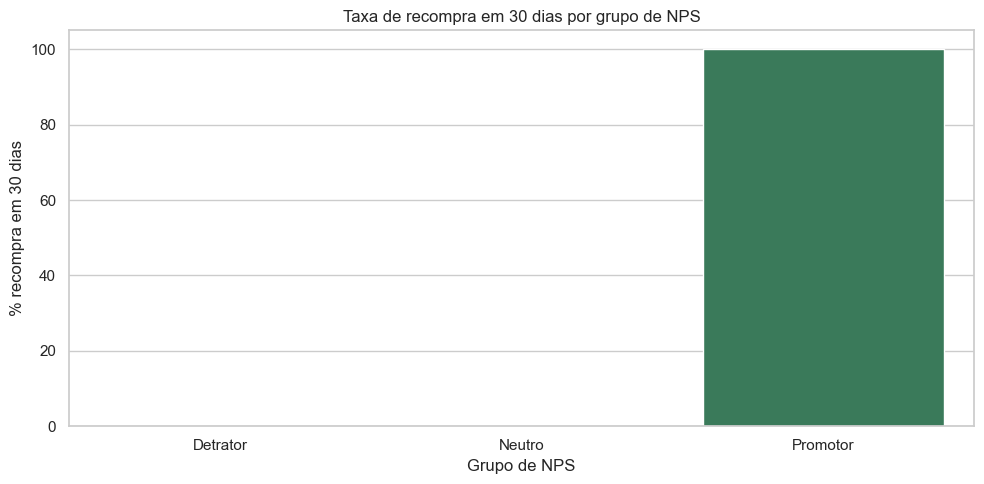

In [62]:
#Analisando a taxa de recompra em 30 dias por grupo de NPS
recompra_nps = (
    nps_eda
    .groupby('nps_group')
    .agg(
        qtd_clientes=('nps_score', 'size'),
        nps_medio=('nps_score', 'mean'),
        recompra_30d_pct=('repeat_purchase_30d', 'mean')
    )
    .reindex(['Detrator', 'Neutro', 'Promotor'])
    .reset_index()
)

recompra_nps['nps_medio'] = recompra_nps['nps_medio'].round(2)
recompra_nps['recompra_30d_pct'] = (recompra_nps['recompra_30d_pct'] * 100).round(1)

display(recompra_nps)

#Gráfico de barras para a taxa de recompra em 30 dias por grupo de NPS
sns.barplot(
    data=recompra_nps,
    x='nps_group',
    y='recompra_30d_pct',
    hue='nps_group',
    palette=['#C53030', '#D69E2E', '#2F855A'],
    legend=False
)

plt.title('Taxa de recompra em 30 dias por grupo de NPS')
plt.xlabel('Grupo de NPS')
plt.ylabel('% recompra em 30 dias')
plt.tight_layout()
plt.show()


### Insight 7 - Satisfação se conecta com recompra

Os resultados mostram que clientes mais satisfeitos tendem a realizar novas compras com maior frequência. Essa relação reforça que o NPS vai além de um indicador de experiência, funcionando também como um importante sinal de retenção e potencial de geração de receita.

Sob a perspectiva do negócio, investir na melhoria da satisfação do cliente não significa apenas aumentar a percepção positiva da marca, mas também fortalecer a fidelização, estimular a recompra e contribuir para o crescimento sustentável dos resultados ao longo do tempo.


## 11. Conclusão

A análise exploratória mostra que a satisfação dos clientes está em um cenário de atenção. A maior parte da base encontra-se classificada como detratora, enquanto a participação de clientes promotores ainda é reduzida, indicando uma oportunidade relevante de melhoria na experiência oferecida pela empresa.

Os resultados apontam que os principais fatores associados à redução do NPS estão concentrados em aspectos operacionais da jornada de compra, com destaque para:

- atrasos na entrega;
- abertura de reclamações;
- múltiplos contatos com o atendimento;
- maior tempo para resolução de problemas;
- níveis mais baixos de CSAT interno.

De forma geral, as evidências sugerem que a satisfação do cliente é influenciada muito mais pela experiência vivida durante a compra do que por características do seu perfil. Em outras palavras, o que determina a percepção final não é quem o cliente é, mas os atritos que ele encontra ao longo da jornada.

Diante desse cenário, as iniciativas prioritárias devem estar voltadas para a melhoria da operação, com foco na redução de atrasos, prevenção de reclamações recorrentes, comunicação proativa com clientes em situações de risco e aumento da eficiência na resolução de problemas. Essas ações têm potencial não apenas para reduzir o volume de detratores, mas também para converter clientes neutros em promotores, gerando impactos positivos na satisfação, retenção e recompra.



# Proposta de Modelo Preditivo

Para antecipar a satisfação do cliente antes da aplicação da pesquisa de NPS, poderiam ser consideradas duas abordagens de modelagem: regressão e classificação.

A primeira possibilidade seria um **modelo de regressão**, com o objetivo de estimar diretamente a nota de `nps_score` em uma escala contínua de 0 a 10. Essa abordagem permitiria prever uma nota aproximada de satisfação para cada cliente ou pedido.

- Do ponto de vista técnico, o modelo aprenderia padrões entre variáveis da jornada, como atraso na entrega, reclamações, contatos com atendimento, tempo de resolução, valor do pedido e características do cliente, e retornaria uma nota estimada de NPS.
- Do ponto de vista de negócio, essa estratégia permitiria acompanhar a expectativa de satisfação média dos clientes e priorizar casos com notas previstas mais baixas.

A segunda possibilidade seria um **modelo de classificação**, com o objetivo de categorizar os clientes em grupos de satisfação. Neste projeto, a classificação poderia seguir a regra definida para o NPS: detratores, neutros e promotores. Também seria possível simplificar o problema para uma classificação binária, separando clientes com maior risco de insatisfação dos demais. Por exemplo, clientes com `nps_score <= 5` poderiam ser classificados como detratores, enquanto os demais seriam tratados como não detratores.

Essa abordagem facilita a criação de alertas e ações operacionais, pois a saída do modelo indica diretamente quais clientes precisam de atenção prioritária.

Entre as duas estratégias, eu adotaria inicialmente um **modelo de classificação binária** para identificar clientes com risco de se tornarem detratores. Essa escolha é mais acionável para o negócio, pois a principal dor da empresa é atuar de forma preventiva antes que a insatisfação se consolide. Em vez de prever exatamente qual nota o cliente dará, o modelo responderia a uma pergunta mais prática: **“este cliente tem alto risco de ser detrator?”**.

- Do ponto de vista técnico, a classificação facilita a definição da variável alvo, a escolha de métricas e a interpretação dos resultados. Métricas como recall, precision, F1-score, AUC-ROC e matriz de confusão ajudariam a avaliar se o modelo está conseguindo identificar corretamente os clientes de maior risco. Nesse caso, o recall da classe detrator seria especialmente importante, pois deixar de identificar um cliente insatisfeito representa perder a oportunidade de agir preventivamente.
- Do ponto de vista de negócio, essa estratégia permitiria transformar o modelo em uma ferramenta de apoio à decisão. Clientes com maior probabilidade de se tornarem detratores poderiam receber ações como comunicação proativa sobre atrasos, priorização no atendimento, acompanhamento especial em casos de reclamação ou compensações em situações críticas. Assim, a empresa deixaria de atuar apenas depois da resposta da pesquisa e passaria a agir antes da piora da experiência.

Mesmo adotando a classificação como estratégia inicial, o modelo de regressão ainda poderia ser útil em uma etapa complementar. Ele permitiria estimar a nota esperada de NPS e acompanhar tendências médias de satisfação por região, tipo de pedido ou canal operacional. Portanto, as duas abordagens são válidas, mas a classificação binária seria a primeira escolha por gerar uma resposta mais simples, direta e aplicável às decisões operacionais.
